In [15]:
import base64
import pickle
import zlib
from typing import Any, Dict, Optional, List, Union

import requests


def _unjson(jsonable: Dict[str, Any]) -> Any:
    """反序列化 _anything_to_json 的输出：base64 -> zlib -> pickle"""
    compressed = base64.b64decode(jsonable["data"].encode("ascii"))
    pickled = zlib.decompress(compressed)
    return pickle.loads(pickled)


class LiberoGymClient:
    """
    严格按你给的 Flask 路由行为封装：
    - create_env: POST /v1/envs/  (Query params)
    - reset_env : POST /v1/envs/<iid>/reset/ (Query seed) -> decode observation only
    - step      : POST /v1/envs/<iid>/step/  (JSON action) -> decode observation + info
    - sample_action: GET /v1/envs/<iid>/action_space/sample/
    - delete_env: DELETE /v1/envs/<iid>/
    """

    def __init__(
        self,
        base_url: str,
        instance_id: Optional[str] = None,
        timeout: int = 30,
        headers: Optional[Dict[str, str]] = None,
        session: Optional[requests.Session] = None,
    ):
        self.base_url = base_url.rstrip("/")
        self.instance_id = instance_id
        self.timeout = timeout
        self.headers = headers or {}
        self.sess = session or requests.Session()

    def _url(self, path: str) -> str:
        return f"{self.base_url}{path}"

    def _request(self, method: str, path: str, *, params=None, json=None) -> requests.Response:
        resp = self.sess.request(
            method=method,
            url=self._url(path),
            params=params,
            json=json,
            headers=self.headers,
            timeout=self.timeout,
        )
        try:
            resp.raise_for_status()
        except requests.HTTPError as e:
            raise requests.HTTPError(f"{e}\nResponse text: {resp.text}") from e
        return resp

    @staticmethod
    def _bool_q(v: bool) -> str:
        # 服务端用 args.get(...).lower() == "true"
        return "true" if v else "false"

    def _iid(self, instance_id: Optional[str]) -> str:
        iid = instance_id or self.instance_id
        if not iid:
            raise ValueError("instance_id 为空，请先创建环境")
        return iid

    # ---------- API methods ----------

    def create_env(
        self,
        env_name: str,
        task_id: int = 0,
        image_size_height: int = 1080,
        image_size_width: int = 1920,
        require_depth: bool = True,
        require_point_cloud: bool = False,  # 以你贴的服务端默认值为准
        num_points: int = 8192,
        camera_names: Union[str, List[str]] = "agentview,robot0_eye_in_hand",
        max_episode_steps: int = 600,
        seed: int = 0,
        enable_pytorch3d_fps: bool = False,
        pointcloud_process_device: str = "cpu",
    ):
        if isinstance(camera_names, list):
            camera_names = ",".join([c.strip() for c in camera_names])

        params = {
            "env_name": env_name,
            "task_id": task_id,
            "image_size_height": image_size_height,
            "image_size_width": image_size_width,
            "require_depth": self._bool_q(require_depth),
            "require_point_cloud": self._bool_q(require_point_cloud),
            "num_points": num_points,
            "camera_names": camera_names,
            "max_episode_steps": max_episode_steps,
            "seed": seed,
            "enable_pytorch3d_fps": self._bool_q(enable_pytorch3d_fps),
            "pointcloud_process_device": pointcloud_process_device,
        }

        data = self._request("POST", "/v1/envs/", params=params).json()
        iid = data["instance_id"]
        self.instance_id = iid
        return (self, iid)

    def reset(
        self,
        seed: int = 0,
        instance_id: Optional[str] = None,
    ):
        """
        严格按服务端代码：
        - observation: _anything_to_json(obs) -> 用 _unjson 解码
        - info: 服务端直接 return info（不做 _anything_to_json）-> 原样返回
        """
        iid = self._iid(instance_id)
        data = self._request("POST", f"/v1/envs/{iid}/reset/", params={"seed": seed}).json()

        obs = _unjson(data["observation"])   # 按代码，必解
        info = data["info"]                 # 按代码，原样返回

        return obs, info

    def step(
        self,
        action: Any,
        instance_id: Optional[str] = None,
    ):
        """
        严格按服务端代码：
        - observation: _anything_to_json(obs) -> 解码
        - info: _anything_to_json(info) -> 解码
        """
        iid = self._iid(instance_id)
        data = self._request("POST", f"/v1/envs/{iid}/step/", json={"action": action}).json()

        obs = _unjson(data["observation"])
        info = _unjson(data["info"])

        return obs, data["reward"], data["terminated"], data["truncated"], info


    def sample_action(self, instance_id: Optional[str] = None) -> Any:
        iid = self._iid(instance_id)
        data = self._request("GET", f"/v1/envs/{iid}/action_space/sample/").json()
        return data["action"]

    def delete(self, instance_id: Optional[str] = None) -> None:
        iid = self._iid(instance_id)
        self._request("DELETE", f"/v1/envs/{iid}/")
        if iid == self.instance_id:
            self.instance_id = None

    # ---------- convenience ----------

    def __enter__(self) -> "LiberoGymClient":
        return self

    def __exit__(self, exc_type, exc, tb) -> None:
        if self.instance_id:
            try:
                self.delete(self.instance_id)
            except Exception:
                pass


In [16]:
cli = LiberoGymClient("http://localhost:40004")

In [17]:
env, iid = cli.create_env(env_name="libero-object-v0", task_id=0)

In [18]:
env.sample_action()

[-0.837018609046936,
 0.9930063486099243,
 -0.5268861651420593,
 -0.8881713151931763,
 -0.20182639360427856,
 -0.8686697483062744,
 0.8738347887992859]

In [19]:
obs, info = env.reset(seed=0)

In [20]:
import matplotlib.pyplot as plt
import cv2
import numpy as np

def display_image(image, depth=False, colormap=cv2.COLORMAP_JET):
    """
    显示图像
    
    参数:
        image: 输入图像
        depth: 是否为深度图，默认False
        colormap: 深度图的伪彩色映射，默认COLORMAP_JET
    """
    if depth:
        # 深度图处理
        # 归一化到 0-255
        depth_normalized = cv2.normalize(image, None, 0, 255, cv2.NORM_MINMAX)
        depth_uint8 = depth_normalized.astype(np.uint8)
        
        # 应用伪彩色
        depth_colored = cv2.applyColorMap(depth_uint8, colormap)
        
        # BGR -> RGB (OpenCV 输出是 BGR)
        depth_colored = cv2.cvtColor(depth_colored, cv2.COLOR_BGR2RGB)
        
        plt.imshow(depth_colored)
    elif image.ndim == 2:
        # 灰度图，直接显示
        plt.imshow(image, cmap='gray')
    elif image.ndim == 3 and image.shape[2] in [3, 4]:
        # 彩色图
        plt.imshow(image)
    else:
        raise ValueError("输入的图像格式不正确")

    plt.axis('off')
    plt.show()

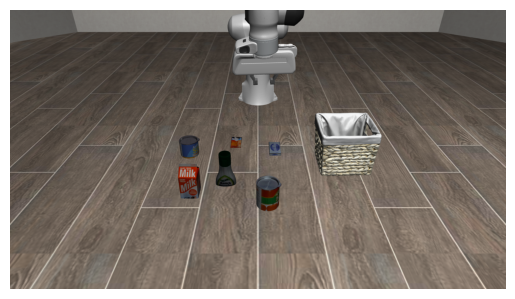

In [21]:
display_image(obs["agentview_image"].transpose(1, 2, 0))

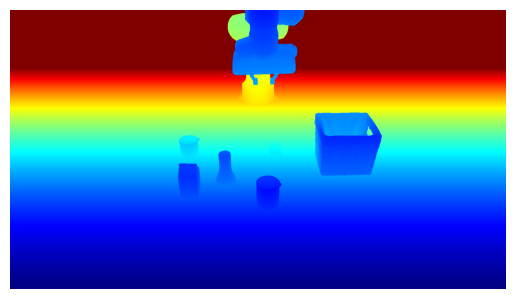

In [22]:
display_image(obs["agentview_depth"], depth=True)

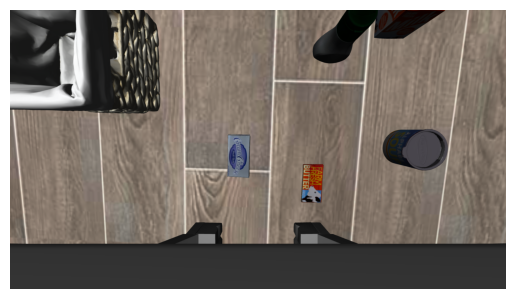

In [23]:
display_image(obs["robot0_eye_in_hand_image"].transpose(1, 2, 0))

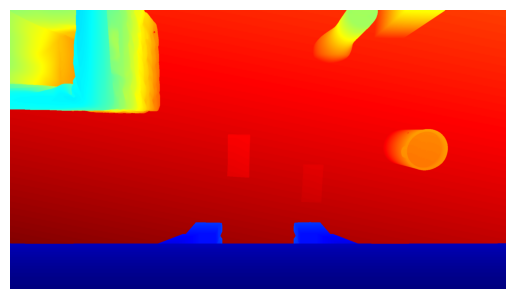

In [24]:
display_image(obs["robot0_eye_in_hand_depth"], depth=True)